🚀 Starting EDA Process...
✅ Loaded raw_data.csv successfully.

--- 1. Generating Distribution Plots ---


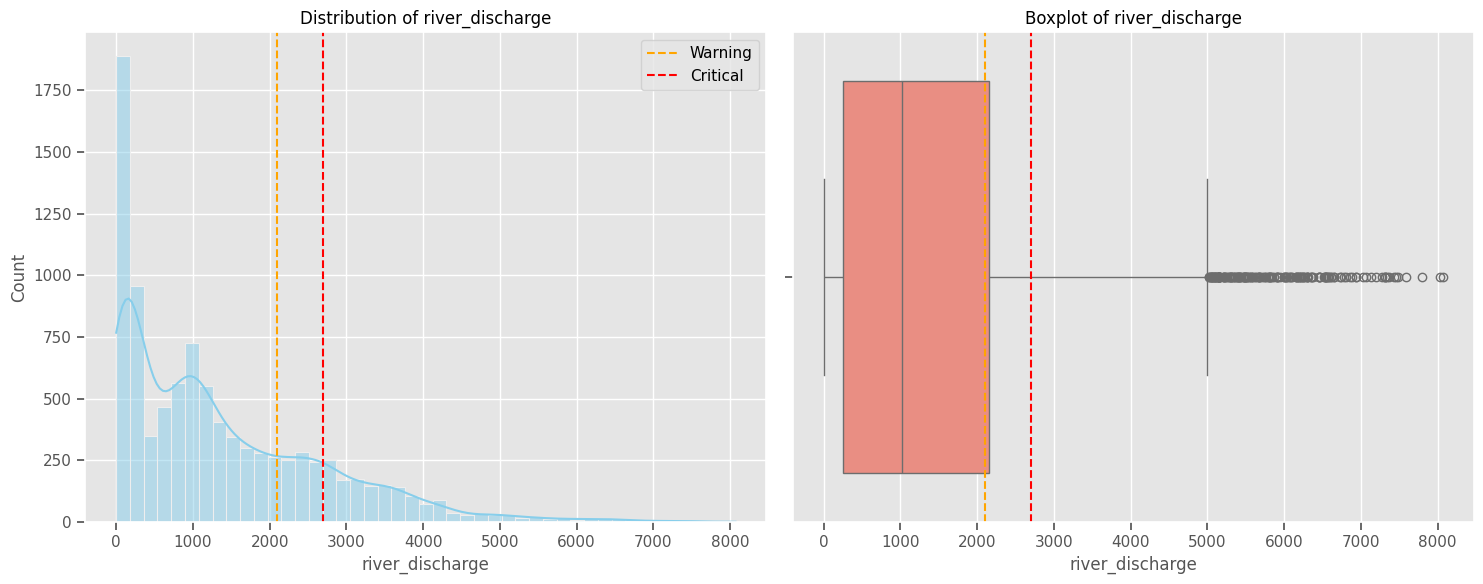


--- 2. Generating Correlation Heatmap for ALL Columns ---


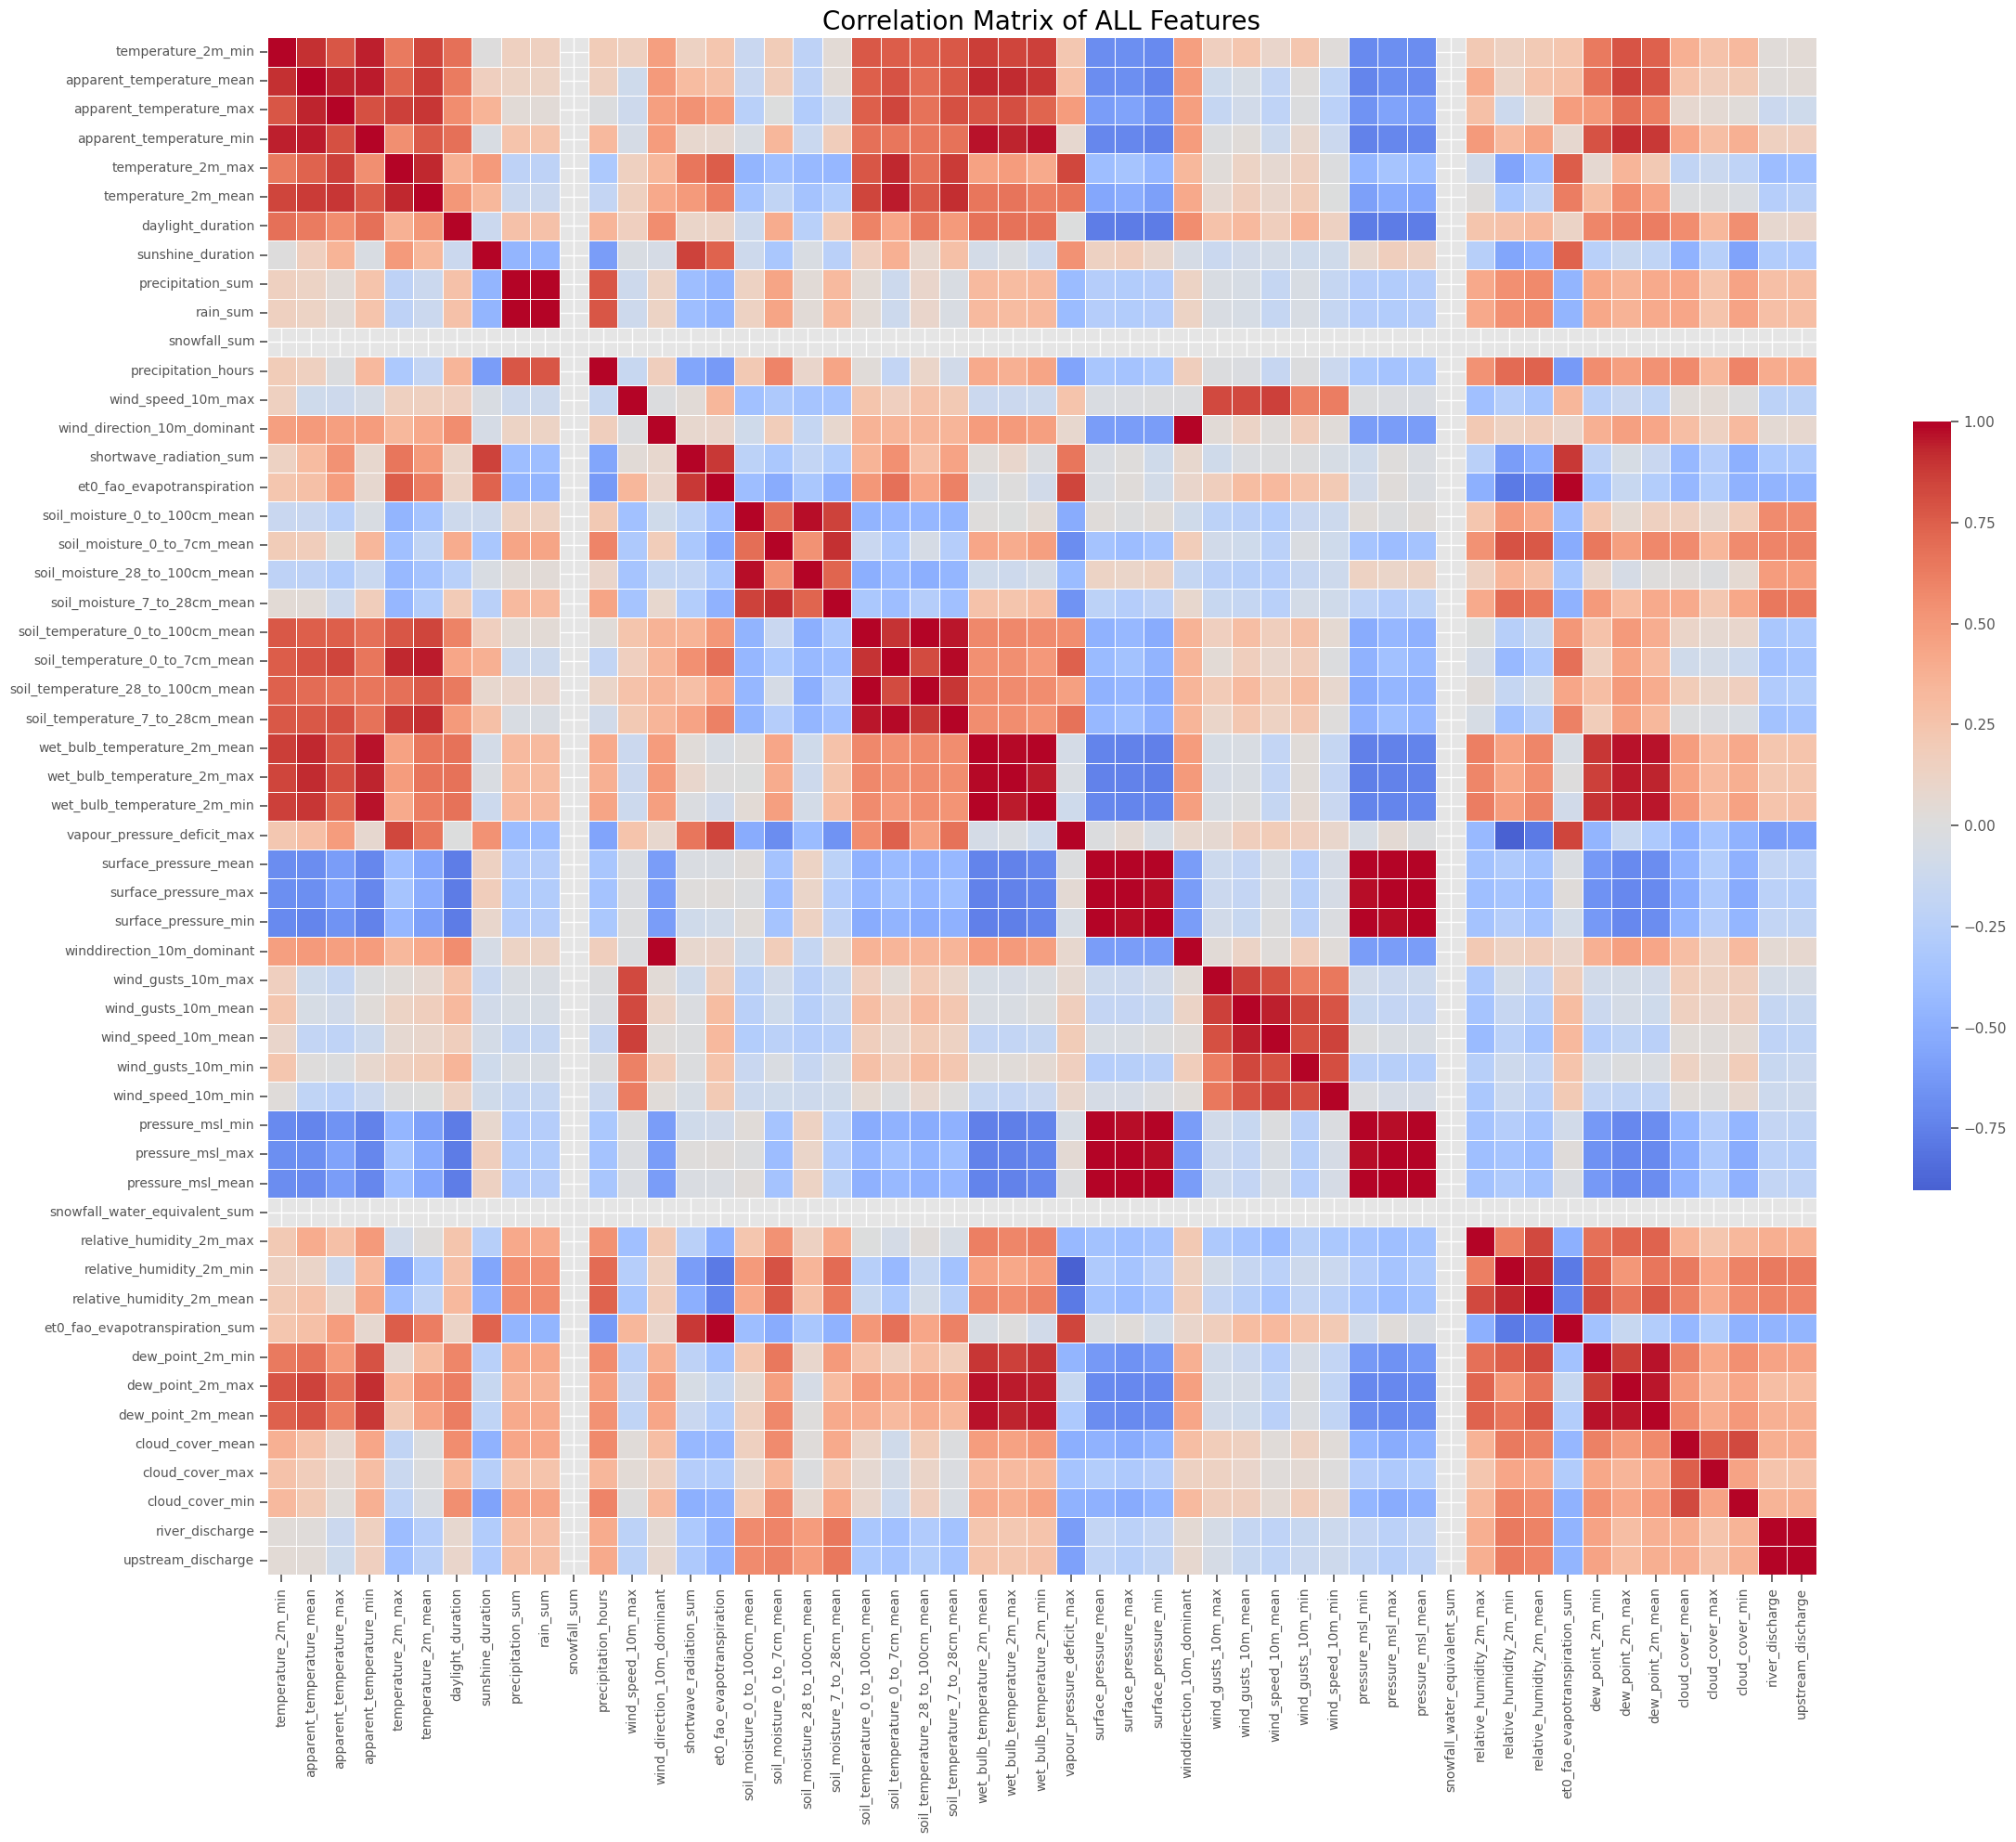

💡 Insight: Heatmap นี้แสดงความสัมพันธ์ของตัวแปรสภาพอากาศและระดับน้ำทั้งหมด
   - สีแดงเข้ม: แปรผันตรงกันมาก (เช่น ฝนตก -> ความชื้นดิน)
   - สีน้ำเงินเข้ม: แปรผกผันกัน

🏆 Top 10 Features correlated with river_discharge:
river_discharge                   1.000000
upstream_discharge                0.993238
soil_moisture_7_to_28cm_mean      0.643591
relative_humidity_2m_min          0.642581
vapour_pressure_deficit_max       0.599950
relative_humidity_2m_mean         0.599406
soil_moisture_0_to_7cm_mean       0.598209
soil_moisture_0_to_100cm_mean     0.564875
soil_moisture_28_to_100cm_mean    0.484518
et0_fao_evapotranspiration_sum    0.471983
et0_fao_evapotranspiration        0.471983
Name: river_discharge, dtype: float64

--- 3. Generating Time-Series Plot ---


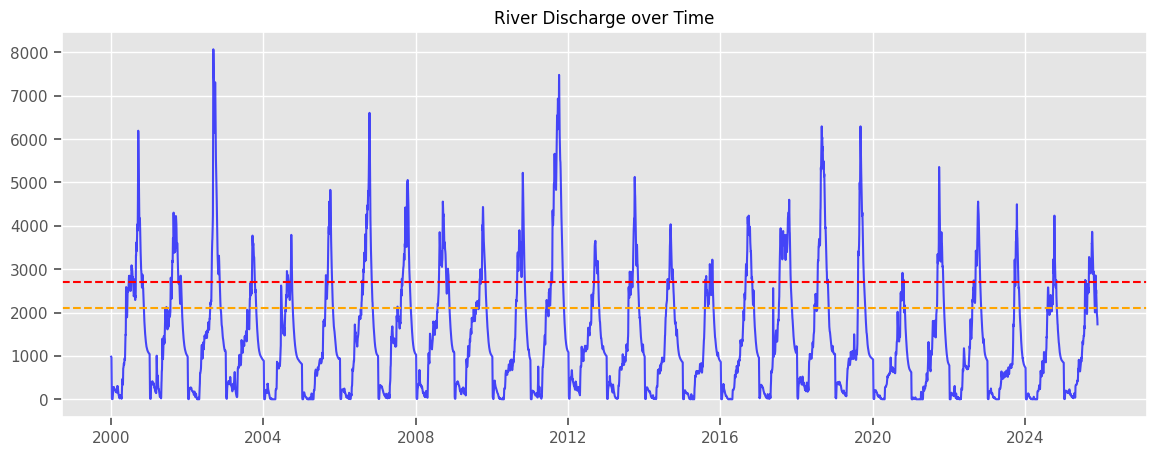


--- 4. Generating Lag Analysis ---


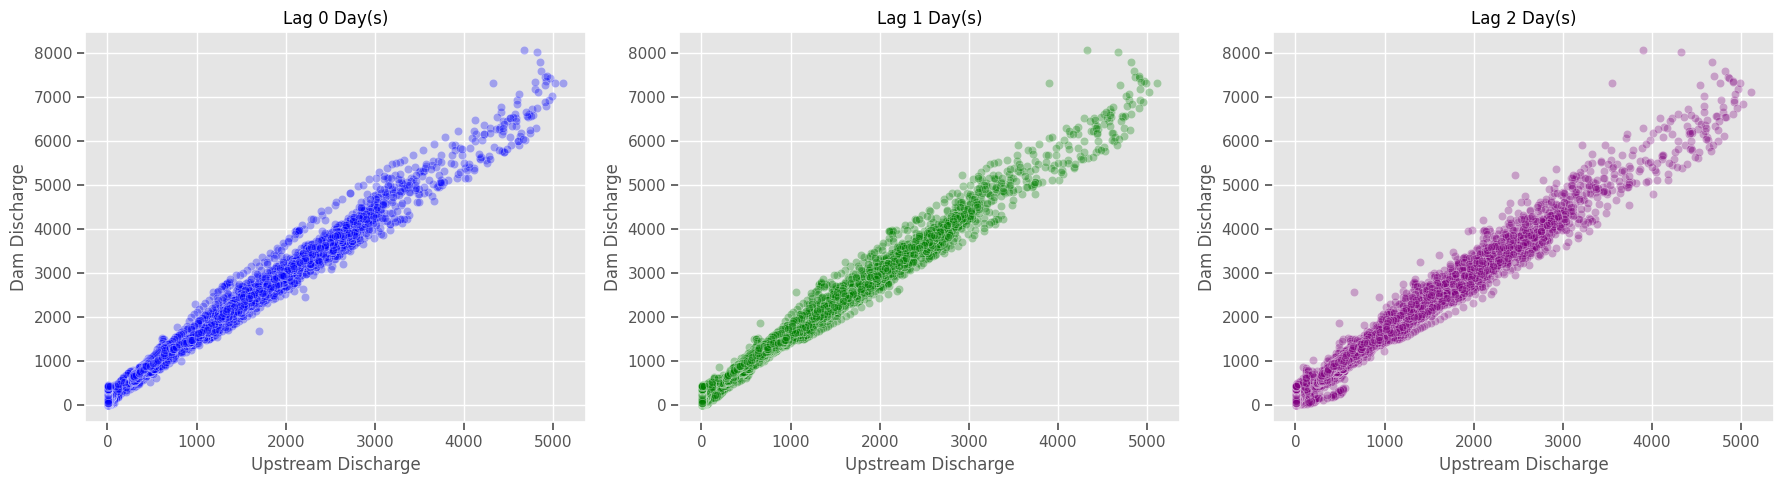

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# ตั้งค่าฟอนต์และสไตล์กราฟ
plt.style.use('ggplot')
sns.set_context("notebook", font_scale=1.0) # ปรับ font scale ลงเล็กน้อยเพื่อให้ heatmap อ่านง่าย

def run_eda():
    print("🚀 Starting EDA Process...")
    
    # 1. Load Data
    try:
        df = pd.read_csv('../data/raw/raw_data.csv')
        print("✅ Loaded raw_data.csv successfully.")
    except FileNotFoundError:
        print("❌ Error: 'raw_data.csv' not found.")
        return

    # Convert date to datetime
    if 'date' in df.columns:
        df['date'] = pd.to_datetime(df['date'])
    
    # --- Data Preparation ---
    if 'location' not in df.columns:
        print("⚠️ Warning: 'location' column not found. Using full dataset.")
        df_target = df.copy()
        df_upstream = df.copy()
    else:
        # แยกข้อมูลระหว่าง Target (เขื่อนเจ้าพระยา) และ Upstream (นครสวรรค์)
        # หมายเหตุ: ชื่อ Location ต้องตรงกับใน CSV
        target_loc = 'ChaoPhraya_Dam'
        upstream_loc = 'NakhonSawan_Muang_Upstream'
        
        df_target = df[df['location'] == target_loc].copy()
        df_upstream = df[df['location'] == upstream_loc].copy()

    # Set Index
    df_target = df_target.set_index('date').sort_index()
    df_upstream = df_upstream.set_index('date').sort_index()

    # Identify Target Column
    target_col = 'river_discharge'
    if target_col not in df_target.columns:
        # พยายามหา column ที่ใกล้เคียง
        candidates = [c for c in df_target.columns if 'discharge' in c or 'flow' in c]
        if candidates:
            target_col = candidates[0]
        else:
            print("❌ Cannot proceed without discharge data.")
            return

    # ==============================================================================
    # 📊 1. Data Distribution (Focus on Target Variable)
    # ==============================================================================
    print("\n--- 1. Generating Distribution Plots ---")
    fig, axes = plt.subplots(1, 2, figsize=(15, 6))
    
    sns.histplot(df_target[target_col], kde=True, ax=axes[0], color='skyblue')
    axes[0].set_title(f'Distribution of {target_col}')
    
    sns.boxplot(x=df_target[target_col], ax=axes[1], color='salmon')
    axes[1].set_title(f'Boxplot of {target_col}')
    
    # Threshold Lines
    for ax in axes:
        ax.axvline(2100, color='orange', linestyle='--', label='Warning')
        ax.axvline(2700, color='red', linestyle='--', label='Critical')
        if ax == axes[0]: ax.legend()

    plt.tight_layout()
    plt.show()

    # ==============================================================================
    # 🔗 2. Full Feature Correlation (ALL COLUMNS)
    # ==============================================================================
    print("\n--- 2. Generating Correlation Heatmap for ALL Columns ---")
    
    # 1. เลือกเฉพาะคอลัมน์ตัวเลขทั้งหมดจาก df_target
    df_corr_all = df_target.select_dtypes(include=[np.number]).copy()
    
    # 2. เพิ่มคอลัมน์ Upstream Discharge เข้าไป (เพราะเป็นตัวแปรสำคัญจากภายนอก)
    if not df_upstream.empty and target_col in df_upstream.columns:
        upstream_series = df_upstream[[target_col]].rename(columns={target_col: 'upstream_discharge'})
        # Merge by index (date)
        df_corr_all = pd.merge(df_corr_all, upstream_series, left_index=True, right_index=True, how='left')

    # ลบ columns ที่เป็น id หรือค่าคงที่ถ้ามี (Optional)
    cols_to_drop = ['id', 'Unnamed: 0']
    df_corr_all = df_corr_all.drop(columns=[c for c in cols_to_drop if c in df_corr_all.columns])

    # 3. คำนวณ Correlation Matrix
    corr_matrix = df_corr_all.corr()

    # 4. Plot Heatmap ขนาดใหญ่
    plt.figure(figsize=(24, 20)) # เพิ่มขนาดให้รองรับทุกคอลัมน์
    sns.heatmap(
        corr_matrix, 
        annot=False, # ปิดตัวเลขถ้าเยอะเกินไป (หรือเปิด True ถ้าต้องการดูค่า)
        cmap='coolwarm', 
        linewidths=0.5,
        center=0,
        cbar_kws={"shrink": .5}
    )
    plt.title('Correlation Matrix of ALL Features', fontsize=20)
    plt.xticks(rotation=90, fontsize=10)
    plt.yticks(rotation=0, fontsize=10)
    plt.tight_layout()
    plt.show()
    
    print("💡 Insight: Heatmap นี้แสดงความสัมพันธ์ของตัวแปรสภาพอากาศและระดับน้ำทั้งหมด")
    print("   - สีแดงเข้ม: แปรผันตรงกันมาก (เช่น ฝนตก -> ความชื้นดิน)")
    print("   - สีน้ำเงินเข้ม: แปรผกผันกัน")
    
    # (Optional) Print Top Correlations with Target
    print(f"\n🏆 Top 10 Features correlated with {target_col}:")
    top_corr = corr_matrix[target_col].abs().sort_values(ascending=False).head(11) # รวมตัวเอง
    print(top_corr)

    # ==============================================================================
    # 📉 3. Temporal Patterns
    # ==============================================================================
    print("\n--- 3. Generating Time-Series Plot ---")
    plt.figure(figsize=(14, 5))
    plt.plot(df_target.index, df_target[target_col], label='Dam Discharge', color='blue', alpha=0.7)
    plt.axhline(2100, color='orange', linestyle='--')
    plt.axhline(2700, color='red', linestyle='--')
    plt.title('River Discharge over Time')
    plt.show()

    # ==============================================================================
    # 📍 4. Lag Analysis
    # ==============================================================================
    print("\n--- 4. Generating Lag Analysis ---")
    if 'upstream_discharge' in df_corr_all.columns:
        df_lag = df_corr_all[[target_col, 'upstream_discharge']].dropna()
        
        fig, axes = plt.subplots(1, 3, figsize=(18, 5))
        lags = [0, 1, 2]
        colors = ['blue', 'green', 'purple']
        
        for i, lag in enumerate(lags):
            if lag == 0:
                x_data = df_lag['upstream_discharge']
                y_data = df_lag[target_col]
            else:
                x_data = df_lag['upstream_discharge'].shift(lag)
                y_data = df_lag[target_col]
            
            # Drop NA generated by shift for plotting
            mask = ~np.isnan(x_data) & ~np.isnan(y_data)
            
            sns.scatterplot(x=x_data[mask], y=y_data[mask], ax=axes[i], alpha=0.3, color=colors[i])
            axes[i].set_title(f'Lag {lag} Day(s)')
            axes[i].set_xlabel('Upstream Discharge')
            axes[i].set_ylabel('Dam Discharge')

        plt.tight_layout()
        plt.show()

if __name__ == "__main__":
    run_eda()